<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/U2_Temperature_Analysis_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:

# =========================================================
# 1. FILE PATHS
# =========================================================
electrical_file = r"u2_electrical_data_6_4_2026_R2.csv"
temp_file       = r"u2_winding_temp_6_4_2026_R2.csv"

# Output folder
output_dir = Path("generator_analysis_outputs")
output_dir.mkdir(exist_ok=True)


In [4]:

# =========================================================
# 2. READ FILES
# Your files are UTF-16 and tab-separated
# =========================================================
elec = pd.read_csv(electrical_file, encoding="utf-16", sep="\t")
temp = pd.read_csv(temp_file, encoding="utf-16", sep="\t")

# Clean column names
elec.columns = elec.columns.str.strip()
temp.columns = temp.columns.str.strip()

print("Electrical columns:")
print(elec.columns.tolist())
print("\nTemperature columns:")
print(temp.columns.tolist())


Electrical columns:
['Timestamp', 'Active_power(MW)', 'Reactive_power(Mvar)', 'UNIT Voltage_AB(kV)', 'UNIT Voltage_BC(kV)', 'UNIT Voltage_CA(kV)', 'UNIT CURRENT PHASE A', 'UNIT CURRENT PHASE B', 'UNIT CURRENT PHASE C', 'FIELD CURRENT', 'FIELD VOLTAGE']

Temperature columns:
['Timestamp', 'STATOR WINDING PHASE U2 TEMP', 'STATOR WINDING PHASE U164 TEMP', 'GENERATOR COOLING WATER INLET TEMP', 'UPPER BEARING OIL COOLER WARM WATER', 'LOWER BEARING OIL COOLER WARM WATER', 'UPPER GUIDE BEARING PAD TEMP', 'LOWER GUIDE BEARING PAD TEMP', 'COLD AIR TEMP', 'HOT AIR TEMP', 'GENERATOR COOLING WATER OUTLET TEMP']


In [5]:
# =========================================================
# 3. PARSE TIMESTAMP
# =========================================================
elec["Timestamp"] = pd.to_datetime(elec["Timestamp"], errors="coerce")
temp["Timestamp"] = pd.to_datetime(temp["Timestamp"], errors="coerce")

# Drop bad timestamps
elec = elec.dropna(subset=["Timestamp"]).copy()
temp = temp.dropna(subset=["Timestamp"]).copy()

# Sort
elec = elec.sort_values("Timestamp").reset_index(drop=True)
temp = temp.sort_values("Timestamp").reset_index(drop=True)

In [6]:
# =========================================================
# 4. MERGE DATASETS
# Use nearest timestamp match
# tolerance can be adjusted if needed
# =========================================================
df = pd.merge_asof(
    elec,
    temp,
    on="Timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("10min")
)

print("\nMerged shape:", df.shape)


Merged shape: (980, 21)


In [7]:
# =========================================================
# 5. RENAME COLUMNS TO SHORTER NAMES
# =========================================================
rename_map = {
    "Active_power(MW)": "MW",
    "Reactive_power(Mvar)": "MVAr",
    "UNIT Voltage_AB(kV)": "V_AB_kV",
    "UNIT Voltage_BC(kV)": "V_BC_kV",
    "UNIT Voltage_CA(kV)": "V_CA_kV",
    "UNIT CURRENT PHASE A": "I_A",
    "UNIT CURRENT PHASE B": "I_B",
    "UNIT CURRENT PHASE C": "I_C",
    "FIELD CURRENT": "Field_Current",
    "FIELD VOLTAGE": "Field_Voltage",
    "FREQUENCY(Hz)": "Frequency_Hz",

    "STATOR WINDING PHASE U2 TEMP": "Winding_U2_Temp",
    "STATOR WINDING PHASE U164 TEMP": "Winding_U164_Temp",
    "COLD AIR TEMP": "Cold_Air_Temp",
    "HOT AIR TEMP": "Hot_Air_Temp",
    "UPPER GUIDE BEARING PAD TEMP": "UGB_Pad_Temp",
    "LOWER GUIDE BEARING PAD TEMP": "LGB_Pad_Temp",
    "UPPER BEARING OIL COOLER WARM WATER": "Upper_Bearing_Warm_Water",
    "LOWER BEARING OIL COOLER WARM WATER": "Lower_Bearing_Warm_Water",
    "GENERATOR COOLING WATER OUTLET TEMP": "Cooling_Water_Outlet_Temp",
    "GENERATOR COOLING WATER INLET TEMP": "Cooling_Water_Inlet_Temp",
}
df = df.rename(columns=rename_map)


In [8]:

# =========================================================
# 6. CHECK REQUIRED COLUMNS
# =========================================================
required_cols = [
    "Timestamp", "MW", "MVAr",
    "I_A", "I_B", "I_C",
    "V_AB_kV", "V_BC_kV", "V_CA_kV",
    "Field_Current", "Field_Voltage",
    "Winding_U2_Temp", "Winding_U164_Temp",
    "Cooling_Water_Inlet_Temp"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

In [9]:

# =========================================================
# 7. BASIC CLEANING
# =========================================================
numeric_cols = [c for c in df.columns if c != "Timestamp"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows where key columns are missing
df = df.dropna(subset=[
    "MW", "MVAr", "I_A", "I_B", "I_C",
    "Winding_U2_Temp", "Winding_U164_Temp"
]).copy()

In [10]:

# =========================================================
# 8. CREATE DERIVED FEATURES
# =========================================================

# Mean voltage
df["V_mean_kV"] = df[["V_AB_kV", "V_BC_kV", "V_CA_kV"]].mean(axis=1)

# Mean current
df["I_mean"] = df[["I_A", "I_B", "I_C"]].mean(axis=1)

# Current imbalance %
df["I_max"] = df[["I_A", "I_B", "I_C"]].max(axis=1)
df["I_min"] = df[["I_A", "I_B", "I_C"]].min(axis=1)
df["I_imbalance_pct"] = np.where(
    df["I_mean"] != 0,
    (df["I_max"] - df["I_min"]) / df["I_mean"] * 100,
    np.nan
)

# Mean, max, min and spread of winding temperatures
df["Winding_Temp_mean"] = df[["Winding_U2_Temp", "Winding_U164_Temp"]].mean(axis=1)
df["Winding_Temp_max"] = df[["Winding_U2_Temp", "Winding_U164_Temp"]].max(axis=1)
df["Winding_Temp_min"] = df[["Winding_U2_Temp", "Winding_U164_Temp"]].min(axis=1)
df["Winding_Temp_spread"] = df["Winding_Temp_max"] - df["Winding_Temp_min"]

if "Cooling_Water_Inlet_Temp" in df.columns:
    df["TempRise_vs_CoolingWater"] = df["Winding_Temp_mean"] - df["Cooling_Water_Inlet_Temp"]
else:
    df["TempRise_vs_CoolingWater"] = np.nan

if "Cold_Air_Temp" in df.columns:
    df["TempRise_vs_ColdAir"] = df["Winding_Temp_mean"] - df["Cold_Air_Temp"]
else:
    df["TempRise_vs_ColdAir"] = np.nan

df["MVA"] = np.sqrt(df["MW"]**2 + df["MVAr"]**2)
df["PF_abs"] = np.where(df["MVA"] != 0, np.abs(df["MW"]) / df["MVA"], np.nan)

df["I_per_MW"] = np.where(df["MW"] != 0, df["I_mean"] / df["MW"], np.nan)

if "Field_Current" in df.columns:
    df["FieldCurrent_per_MW"] = np.where(df["MW"] != 0, df["Field_Current"] / df["MW"], np.nan)
else:
    df["FieldCurrent_per_MW"] = np.nan

# basic operation filter
df["MW_diff_abs"] = df["MW"].diff().abs()
df = df[
    (df["MW"] > 20) &
    (df["MW_diff_abs"].fillna(0) < 15)
].copy()

In [11]:
# =========================================================
# 9. OPTIONAL OPERATION FILTER
# Keep only meaningful loaded operation
# You can adjust MW threshold
# =========================================================
df["MW_diff_abs"] = df["MW"].diff().abs()

steady_df = df[
    (df["MW"] > 20) &
    (df["MW_diff_abs"].fillna(0) < 15)
].copy()

print("\nRows before steady filter:", len(df))
print("Rows after steady filter :", len(steady_df))

# Use steady_df for most analysis
analysis_df = steady_df.copy()


Rows before steady filter: 655
Rows after steady filter : 595


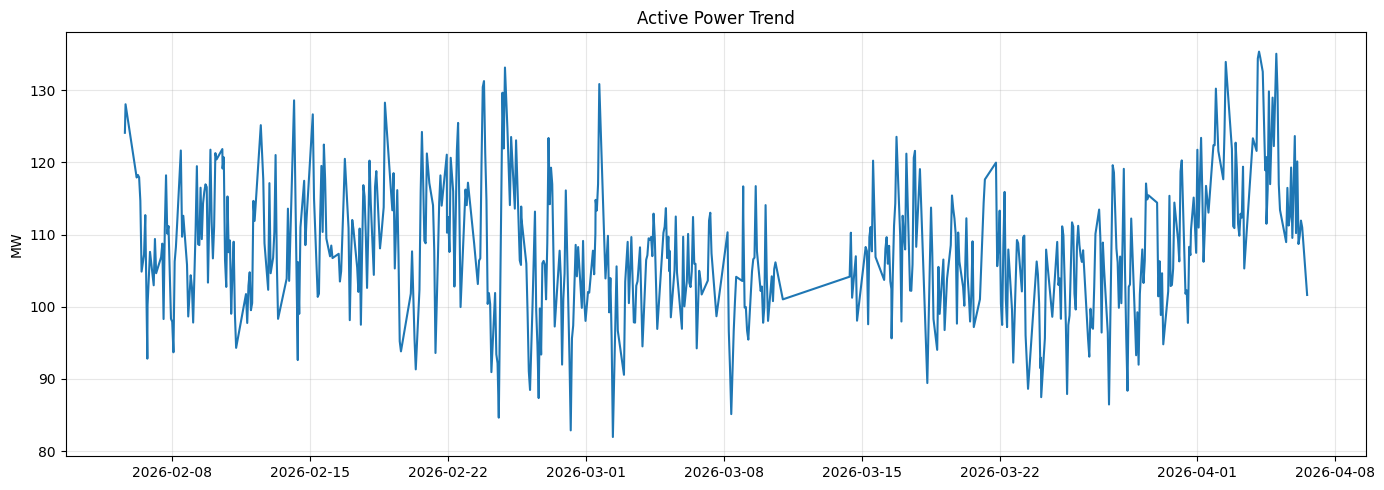

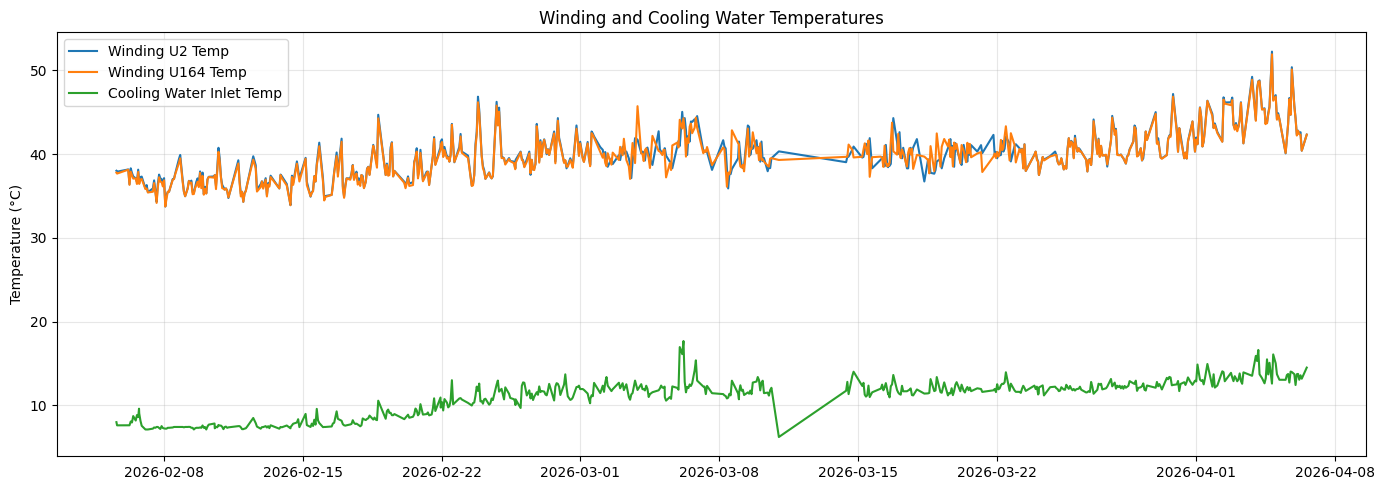

In [12]:
# =========================================================
# 10. TIME TREND PLOTS
# =========================================================
plt.figure(figsize=(14, 5))
plt.plot(analysis_df["Timestamp"], analysis_df["MW"], label="MW")
plt.ylabel("MW")
plt.title("Active Power Trend")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "01_MW_trend.png", dpi=200)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(analysis_df["Timestamp"], analysis_df["Winding_U2_Temp"], label="Winding U2 Temp")
plt.plot(analysis_df["Timestamp"], analysis_df["Winding_U164_Temp"], label="Winding U164 Temp")
plt.plot(analysis_df["Timestamp"], analysis_df["Cooling_Water_Inlet_Temp"], label="Cooling Water Inlet Temp")
plt.legend()
plt.ylabel("Temperature (°C)")
plt.title("Winding and Cooling Water Temperatures")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "02_temperature_trend.png", dpi=200)
plt.show()

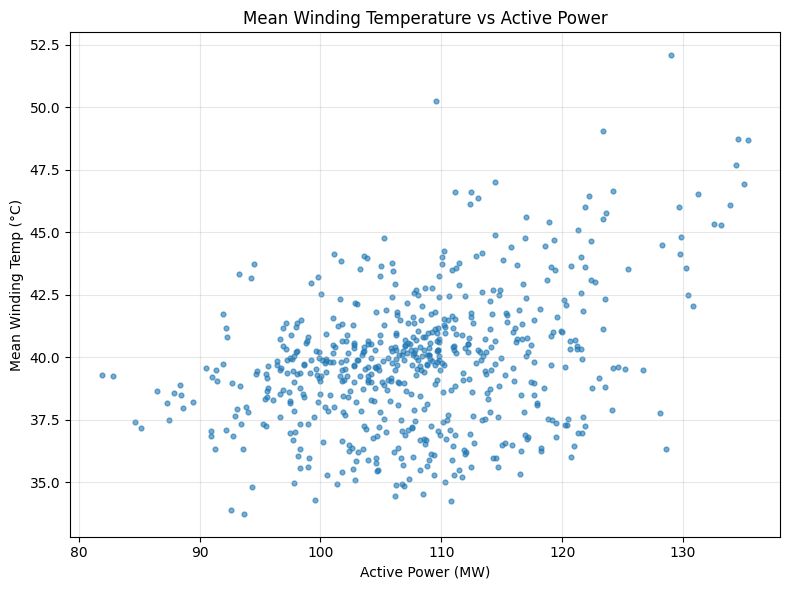

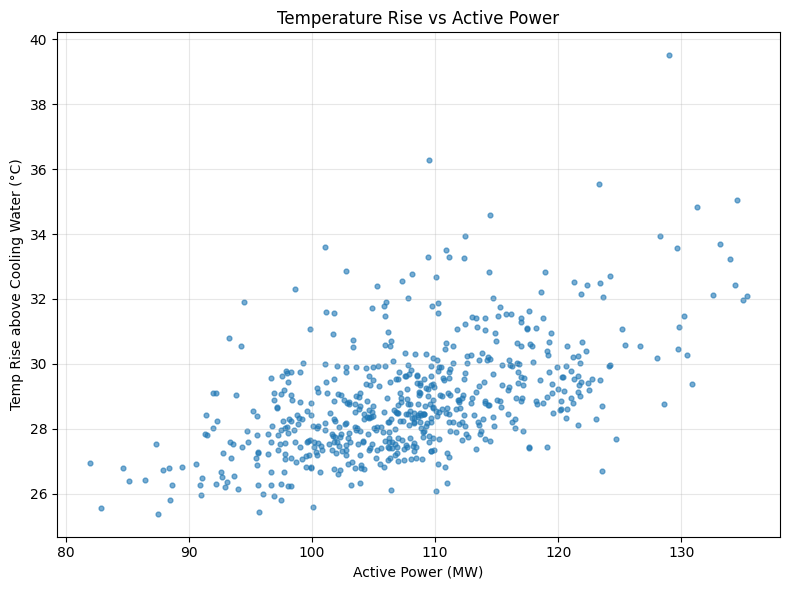

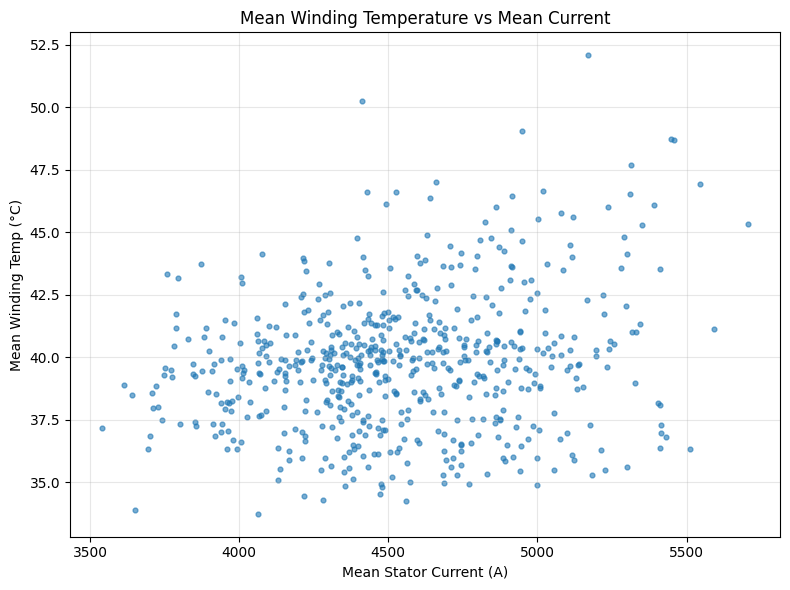

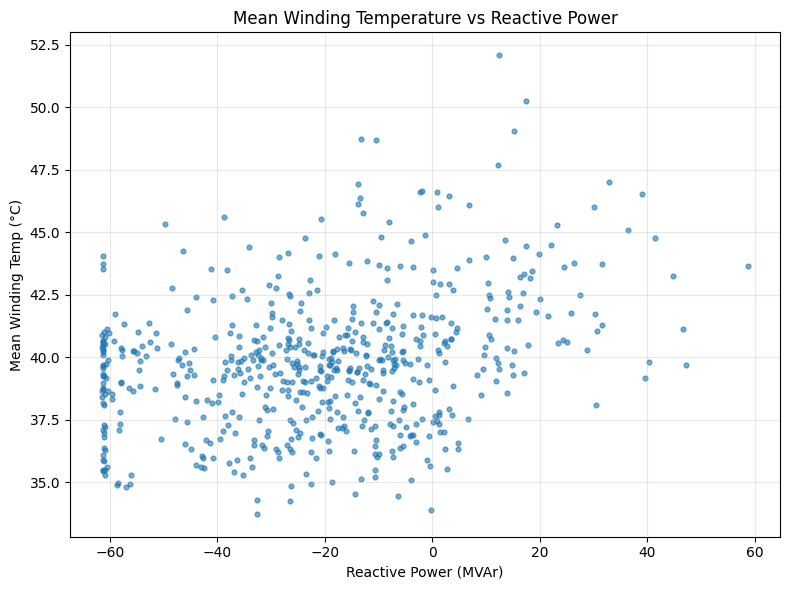

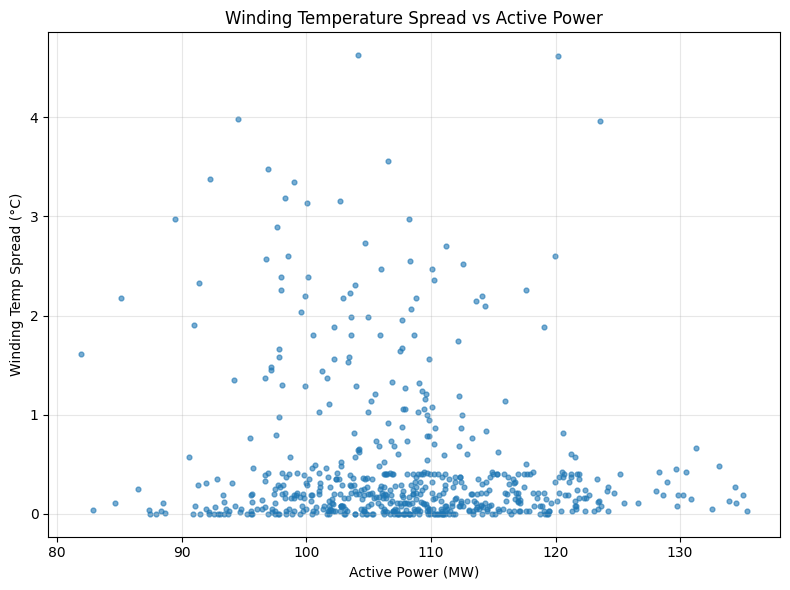

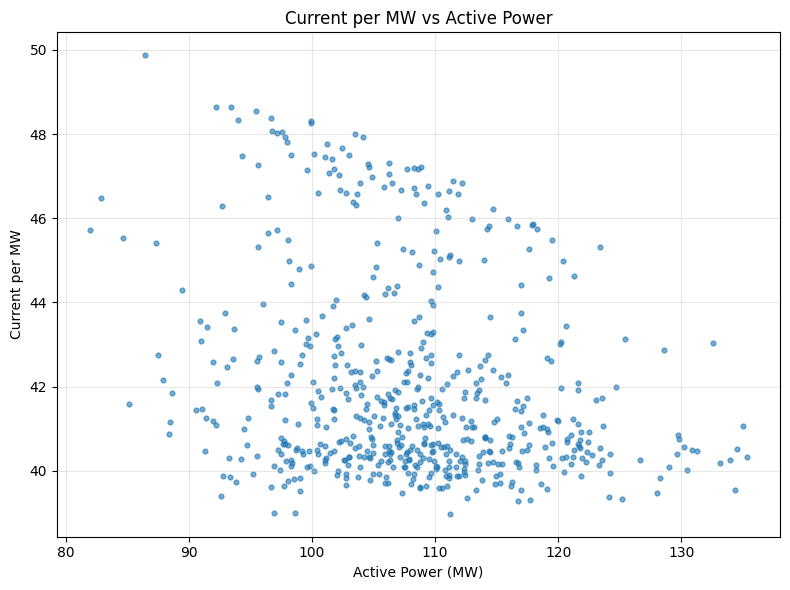

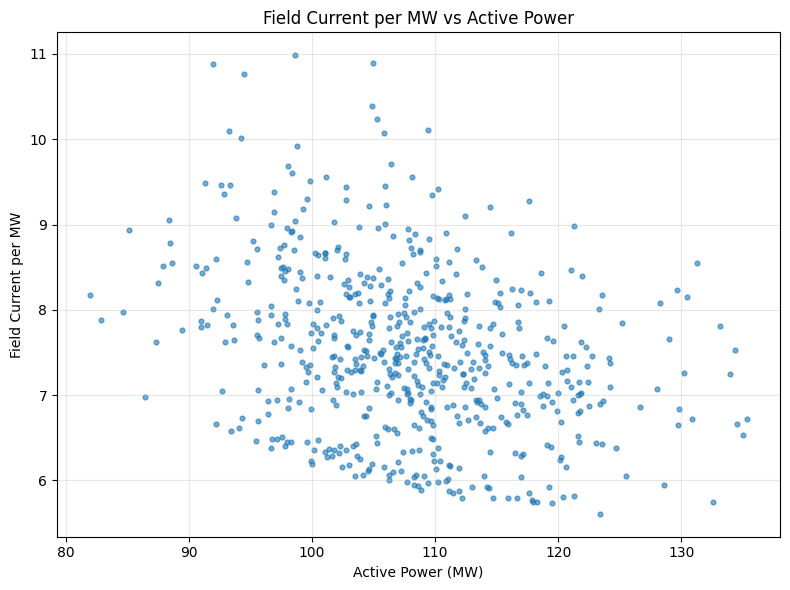

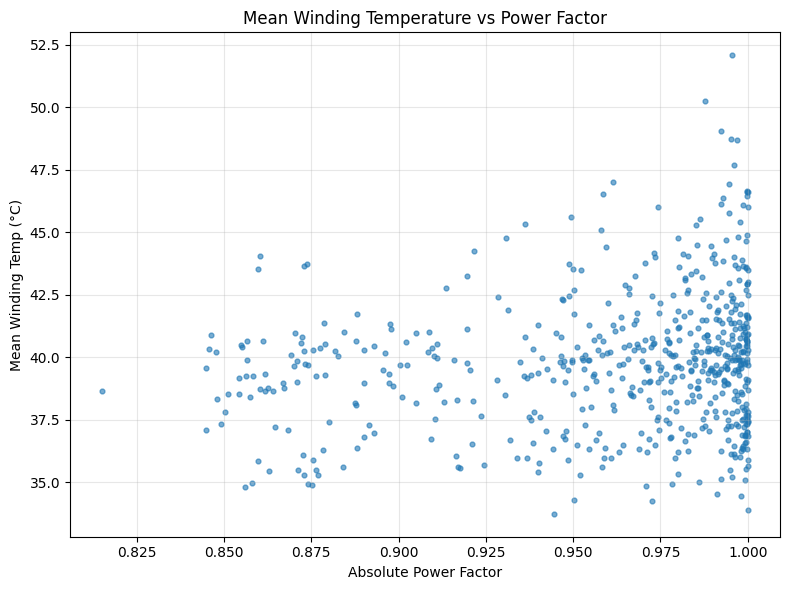

In [13]:


# =========================================================
# 11. SCATTER PLOTS
# =========================================================
def save_scatter(x, y, xlabel, ylabel, title, filename):
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, s=12, alpha=0.6)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

save_scatter(
    analysis_df["MW"], analysis_df["Winding_Temp_mean"],
    "Active Power (MW)", "Mean Winding Temp (°C)",
    "Mean Winding Temperature vs Active Power",
    "03_temp_mean_vs_MW.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["TempRise_vs_CoolingWater"],
    "Active Power (MW)", "Temp Rise above Cooling Water (°C)",
    "Temperature Rise vs Active Power",
    "04_temp_rise_vs_MW.png"
)

save_scatter(
    analysis_df["I_mean"], analysis_df["Winding_Temp_mean"],
    "Mean Stator Current (A)", "Mean Winding Temp (°C)",
    "Mean Winding Temperature vs Mean Current",
    "05_temp_mean_vs_current.png"
)

save_scatter(
    analysis_df["MVAr"], analysis_df["Winding_Temp_mean"],
    "Reactive Power (MVAr)", "Mean Winding Temp (°C)",
    "Mean Winding Temperature vs Reactive Power",
    "06_temp_mean_vs_MVAr.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["Winding_Temp_spread"],
    "Active Power (MW)", "Winding Temp Spread (°C)",
    "Winding Temperature Spread vs Active Power",
    "07_temp_spread_vs_MW.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["I_per_MW"],
    "Active Power (MW)", "Current per MW",
    "Current per MW vs Active Power",
    "08_current_per_MW_vs_MW.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["FieldCurrent_per_MW"],
    "Active Power (MW)", "Field Current per MW",
    "Field Current per MW vs Active Power",
    "09_fieldcurrent_per_MW_vs_MW.png"
)

save_scatter(
    analysis_df["PF_abs"], analysis_df["Winding_Temp_mean"],
    "Absolute Power Factor", "Mean Winding Temp (°C)",
    "Mean Winding Temperature vs Power Factor",
    "10_temp_mean_vs_PF.png"
)


In [14]:

# =========================================================
# 12. MW BIN ANALYSIS
# =========================================================
mw_bins = np.arange(20, 151, 10)
analysis_df["MW_bin"] = pd.cut(analysis_df["MW"], bins=mw_bins, right=False)

mw_summary = analysis_df.groupby("MW_bin", observed=False).agg(
    count=("MW", "size"),
    MW_mean=("MW", "mean"),
    MVAr_mean=("MVAr", "mean"),
    PF_mean=("PF_abs", "mean"),
    I_mean_mean=("I_mean", "mean"),
    I_imbalance_pct_mean=("I_imbalance_pct", "mean"),
    Winding_Temp_mean_mean=("Winding_Temp_mean", "mean"),
    Winding_Temp_mean_max=("Winding_Temp_mean", "max"),
    TempRise_mean_vs_CoolingWater_mean=("TempRise_vs_CoolingWater", "mean"),
    TempRise_mean_vs_CoolingWater_max=("TempRise_vs_CoolingWater", "max"),
    Winding_Temp_spread_mean=("Winding_Temp_spread", "mean"),
    Winding_Temp_spread_max=("Winding_Temp_spread", "max"),
    I_per_MW_mean=("I_per_MW", "mean"),
    FieldCurrent_per_MW_mean=("FieldCurrent_per_MW", "mean"),
).reset_index()

mw_summary.to_csv(output_dir / "mw_bin_summary.csv", index=False)

In [15]:


# =========================================================
# 13. TEMPERATURE MODEL
# Predict expected winding temperature
# =========================================================
model_features = [
    "MW",
    "MVAr",
    "I_mean",
    "V_mean_kV",
    "Field_Current",
    "Cooling_Water_Inlet_Temp"
]

model_df = analysis_df.dropna(subset=model_features + ["Winding_Temp_mean"]).copy()

X = model_df[model_features]
y = model_df["Winding_Temp_mean"]

model = LinearRegression()
model.fit(X, y)

model_df["Winding_Temp_pred"] = model.predict(X)
model_df["Temp_residual"] = model_df["Winding_Temp_mean"] - model_df["Winding_Temp_pred"]

r2 = r2_score(y, model_df["Winding_Temp_pred"])
mae = mean_absolute_error(y, model_df["Winding_Temp_pred"])

print("\nTemperature model performance:")
print("R2  =", round(r2, 4))
print("MAE =", round(mae, 4), "°C")

coef_table = pd.DataFrame({
    "Feature": model_features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=np.abs, ascending=False)

coef_table.to_csv(output_dir / "temperature_model_coefficients.csv", index=False)


Temperature model performance:
R2  = 0.8081
MAE = 0.8791 °C


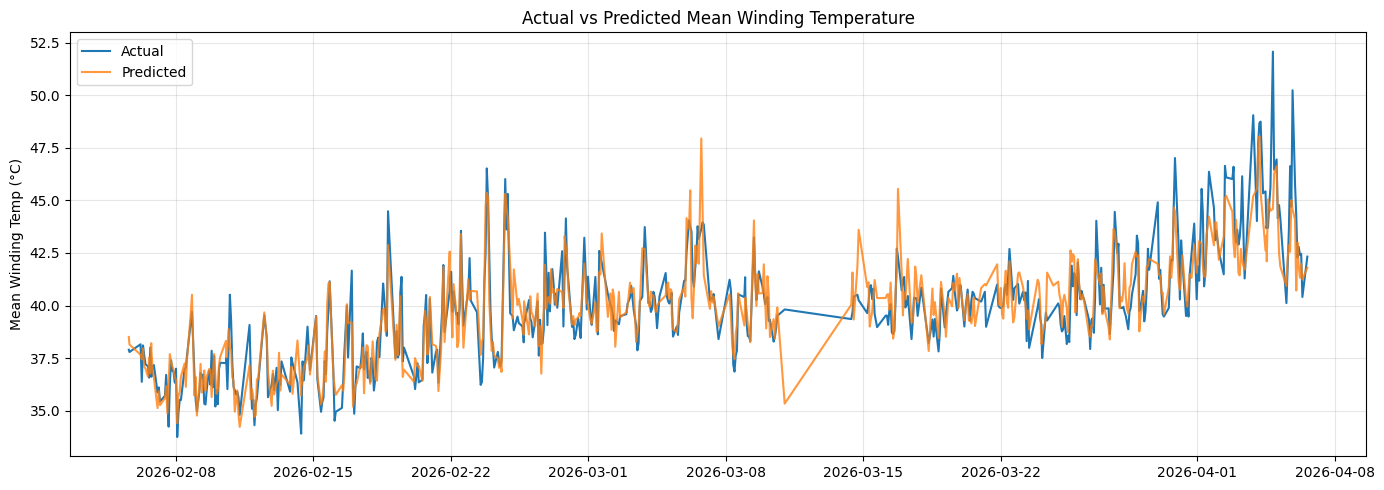

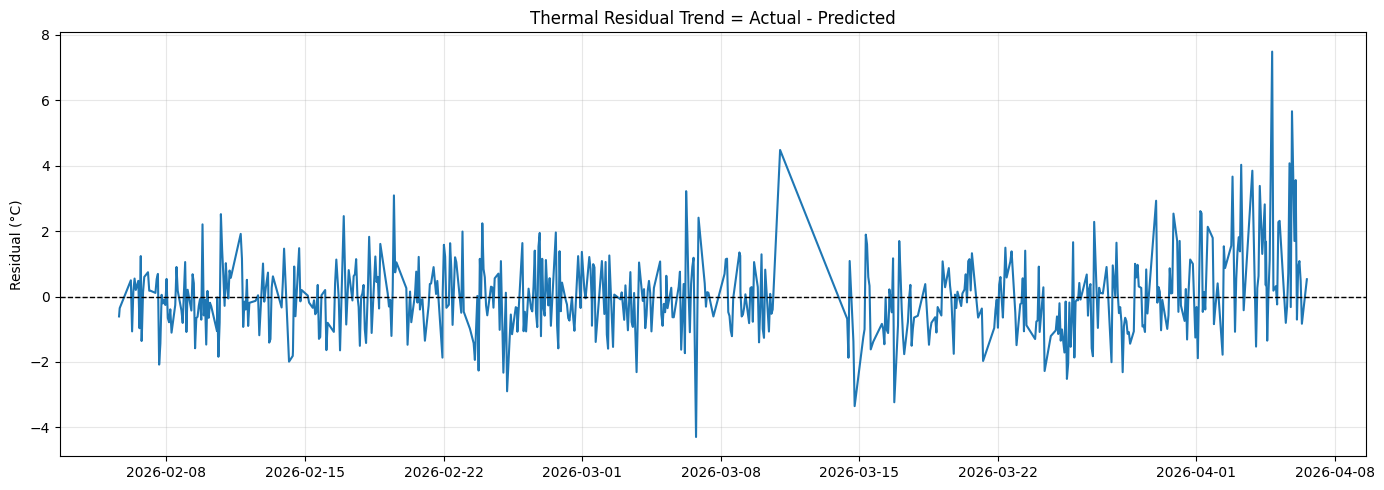


Residual alarm threshold (95% abs): 2.277 °C
Residual alarm events: 30


In [16]:

# =========================================================
# 14. RESIDUAL ANALYSIS
# =========================================================
plt.figure(figsize=(14, 5))
plt.plot(model_df["Timestamp"], model_df["Winding_Temp_mean"], label="Actual")
plt.plot(model_df["Timestamp"], model_df["Winding_Temp_pred"], label="Predicted", alpha=0.8)
plt.legend()
plt.ylabel("Mean Winding Temp (°C)")
plt.title("Actual vs Predicted Mean Winding Temperature")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "11_actual_vs_predicted_temp.png", dpi=200)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(model_df["Timestamp"], model_df["Temp_residual"])
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylabel("Residual (°C)")
plt.title("Thermal Residual Trend = Actual - Predicted")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "12_temp_residual_trend.png", dpi=200)
plt.show()

# Flag abnormal residuals using 95th percentile absolute threshold
res_thr = model_df["Temp_residual"].abs().quantile(0.95)
model_df["Residual_Alarm"] = model_df["Temp_residual"].abs() > res_thr

residual_events = model_df[model_df["Residual_Alarm"]].copy()
residual_events.to_csv(output_dir / "residual_alarm_events.csv", index=False)

print("\nResidual alarm threshold (95% abs):", round(res_thr, 3), "°C")
print("Residual alarm events:", len(residual_events))

In [17]:

# =========================================================
# 15. EXTRA HEALTH FLAGS
# =========================================================
analysis_df["High_TempSpread_Flag"] = analysis_df["Winding_Temp_spread"] > 2.0
analysis_df["High_Iimbalance_Flag"] = analysis_df["I_imbalance_pct"] > 5.0
analysis_df["Low_PF_Flag"] = analysis_df["PF_abs"] < 0.90
analysis_df["High_TempRise_Flag"] = analysis_df["TempRise_vs_CoolingWater"] > analysis_df["TempRise_vs_CoolingWater"].quantile(0.95)

health_summary = pd.DataFrame({
    "Metric": [
        "Rows_analyzed",
        "High_TempSpread_rows",
        "High_Iimbalance_rows",
        "Low_PF_rows",
        "High_TempRise_rows"
    ],
    "Value": [
        len(analysis_df),
        analysis_df["High_TempSpread_Flag"].sum(),
        analysis_df["High_Iimbalance_Flag"].sum(),
        analysis_df["Low_PF_Flag"].sum(),
        analysis_df["High_TempRise_Flag"].sum()
    ]
})

health_summary.to_csv(output_dir / "health_flag_summary.csv", index=False)

In [18]:
# =========================================================
# 16. DAILY SUMMARY
# =========================================================
analysis_df["Date"] = analysis_df["Timestamp"].dt.date

daily_summary = analysis_df.groupby("Date").agg(
    MW_mean=("MW", "mean"),
    MW_max=("MW", "max"),
    MVAr_mean=("MVAr", "mean"),
    PF_mean=("PF_abs", "mean"),
    I_mean=("I_mean", "mean"),
    I_imbalance_pct_mean=("I_imbalance_pct", "mean"),
    Winding_Temp_mean=("Winding_Temp_mean", "mean"),
    Winding_Temp_max=("Winding_Temp_max", "max"),
    TempRise_mean=("TempRise_vs_CoolingWater", "mean"),
    TempRise_max=("TempRise_vs_CoolingWater", "max"),
    TempSpread_mean=("Winding_Temp_spread", "mean"),
    TempSpread_max=("Winding_Temp_spread", "max"),
    FieldCurrent_mean=("Field_Current", "mean"),
).reset_index()

daily_summary.to_csv(output_dir / "daily_summary.csv", index=False)

In [19]:


# =========================================================
# 17. SAVE FINAL DATASETS
# =========================================================
df.to_csv(output_dir / "merged_full_dataset.csv", index=False)
analysis_df.to_csv(output_dir / "merged_filtered_analysis_dataset.csv", index=False)
model_df.to_csv(output_dir / "model_dataset_with_predictions.csv", index=False)

# =========================================================
# 18. PRINT IMPORTANT QUICK RESULTS
# =========================================================
print("\n===== QUICK RESULTS =====")
print("Date range:", analysis_df["Timestamp"].min(), "to", analysis_df["Timestamp"].max())
print("Average MW:", round(analysis_df["MW"].mean(), 2))
print("Average PF:", round(analysis_df["PF_abs"].mean(), 4))
print("Average winding temp:", round(analysis_df["Winding_Temp_mean"].mean(), 2), "°C")
print("Max winding temp:", round(analysis_df["Winding_Temp_max"].max(), 2), "°C")
print("Average temp rise:", round(analysis_df["TempRise_vs_CoolingWater"].mean(), 2), "°C")
print("Max temp rise:", round(analysis_df["TempRise_vs_CoolingWater"].max(), 2), "°C")
print("Average temp spread:", round(analysis_df["Winding_Temp_spread"].mean(), 2), "°C")
print("Max temp spread:", round(analysis_df["Winding_Temp_spread"].max(), 2), "°C")
print("Average current imbalance:", round(analysis_df["I_imbalance_pct"].mean(), 2), "%")
print("Max current imbalance:", round(analysis_df["I_imbalance_pct"].max(), 2), "%")

print("\nFiles saved in folder:", output_dir.resolve())
print("\nDone.")



===== QUICK RESULTS =====
Date range: 2026-02-05 14:45:00 to 2026-04-06 14:20:00
Average MW: 107.97
Average PF: 0.9612
Average winding temp: 39.79 °C
Max winding temp: 52.25 °C
Average temp rise: 28.9 °C
Max temp rise: 39.51 °C
Average temp spread: 0.48 °C
Max temp spread: 4.63 °C
Average current imbalance: 5.27 %
Max current imbalance: 7.77 %

Files saved in folder: /content/generator_analysis_outputs

Done.
